# 🛒 E-Commerce Customer & Sales Analytics

## 📌 Project Introduction

This project analyzes the **Online Retail Dataset** from the UCI Machine Learning Repository to explore sales performance, product performance, customer behavior, and geographic sales patterns.

Using **Python**, the project focuses on data cleaning, exploratory data analysis, customer analytics, RFM customer segmentation, and cohort analysis to extract meaningful business insights from transaction data.

## 🎯 Main Goals

- Understand overall sales and transaction trends.
- Identify high-performing products and markets.
- Analyze customer purchasing behavior.
- Segment customers based on their value and engagement.
- Evaluate customer retention over time.
- Provide data-driven business insights and recommendations.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

# 1. Data Loading & Understanding

In this step, we load the raw **Online Retail Dataset** and perform an initial inspection of the data.

The main purpose is to understand the dataset structure, data types, missing values, duplicate records, and basic transaction information before starting the data cleaning process.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load raw dataset
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_excel(
    "/content/drive/MyDrive/E-Commerce-Analytics/data/Online Retail.xlsx"
)

# Basic inspection
print("Dataset shape:", df.shape)

display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Data types:


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Exact duplicate rows: 5268


# 2. Data Cleaning & Preparation

In this step, we clean and prepare the transaction data for analysis.

The cleaning process focuses on identifying non-sales records, cancellations, accounting adjustments, and duplicate transactions while preserving valid business transactions.

The cleaned dataset will then be used for the subsequent sales, product, and customer analysis.

In [2]:
# 2. DATA CLEANING & PREPARATION
# Keep the original dataset for audit purposes
df_raw = df.copy()

# Columns used to identify exact duplicate transactions
group_cols = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country"
]

# 2.1 Separate non-cancellation stock adjustments

negative_qty_no_c = (
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
)

stock_adjustments_qty = df.loc[negative_qty_no_c].copy()

# Remove these records from the main dataset
df = df.loc[~negative_qty_no_c].copy()


# 2.2 Handle non-positive UnitPrice

negative_price = df["UnitPrice"] < 0
zero_price = df["UnitPrice"] == 0

# Zero-price records without CustomerID
zero_no_cust = (
    zero_price &
    df["CustomerID"].isna()
)

# Zero-price records with CustomerID and special adjustment codes
manual_adj = (
    zero_price &
    df["CustomerID"].notna() &
    df["StockCode"].astype(str).isin(["M", "PADS"])
)

# Keep valid zero-price transactions such as free gifts
free_gift = (
    zero_price &
    df["CustomerID"].notna() &
    ~manual_adj
)

# Accounting / manual adjustments
accounting_adjustments = df.loc[
    negative_price | manual_adj
].copy()

# Stock-related zero-price adjustments
stock_adjustments_price = df.loc[
    zero_no_cust
].copy()

# Remove invalid adjustment records from the main dataset
df = df.loc[
    ~(negative_price | manual_adj | zero_no_cust)
].copy()


# Combine all stock adjustments for audit
stock_adjustments = pd.concat(
    [
        stock_adjustments_qty,
        stock_adjustments_price
    ],
    axis=0
).sort_index()

# 2.3 Remove exact duplicate transaction
# Keep a copy before deduplication for audit
df_before_dedup = df.copy()

duplicate_mask = df.duplicated(
    subset=group_cols,
    keep="first"
)

# Store removed duplicate rows
duplicate_rows_removed = df.loc[
    duplicate_mask
].copy()

# Remove exact duplicates
df_clean = df.loc[
    ~duplicate_mask
].copy()

# Use the cleaned dataset as the official dataset
df = df_clean.copy()

# 2.4 Cleaning summary

print("=== DATA CLEANING SUMMARY ===")

print("Original rows:", len(df_raw))
print("Stock adjustments:", len(stock_adjustments))
print("Accounting adjustments:", len(accounting_adjustments))
print("Exact duplicate rows removed:", len(duplicate_rows_removed))
print("Final rows:", len(df))

=== DATA CLEANING SUMMARY ===
Original rows: 541909
Stock adjustments: 2475
Accounting adjustments: 9
Exact duplicate rows removed: 5263
Final rows: 534162


### 2.5 Final Data Quality Check

After cleaning, the dataset is validated again to ensure that duplicate transactions and invalid adjustment records have been handled correctly.

The final checks confirm the dataset size, remaining cancellations, zero-price transactions, missing values, date range, and key transaction metrics.

In [3]:
# ============================================================
# 2.5 FINAL DATA QUALITY CHECK
# ============================================================

sales = df["Quantity"] * df["UnitPrice"]

print("=== FINAL DATA QUALITY CHECK ===")

print("Shape:", df.shape)

print(
    "Exact duplicates:",
    df.duplicated(subset=group_cols).sum()
)

print(
    "Quantity <= 0:",
    (df["Quantity"] <= 0).sum()
)

print(
    "Cancellations:",
    df["InvoiceNo"]
      .astype(str)
      .str.startswith("C")
      .sum()
)

print(
    "UnitPrice <= 0:",
    (df["UnitPrice"] <= 0).sum()
)

print(
    "Missing CustomerID:",
    df["CustomerID"].isna().sum()
)

print(
    "Missing Description:",
    df["Description"].isna().sum()
)

print(
    "Date range:",
    df["InvoiceDate"].min(),
    "→",
    df["InvoiceDate"].max()
)

print(
    "Unique InvoiceNo:",
    df["InvoiceNo"].nunique()
)

print(
    "Unique CustomerID:",
    df["CustomerID"].nunique()
)

print(
    "Total Quantity:",
    df["Quantity"].sum()
)

print(
    "Total Sales:",
    sales.sum()
)

print("\n=== AUDIT SUMMARY ===")

print(
    "Stock adjustments:",
    len(stock_adjustments)
)

print(
    "Accounting adjustments:",
    len(accounting_adjustments)
)

print(
    "Exact duplicates removed:",
    len(duplicate_rows_removed)
)

=== FINAL DATA QUALITY CHECK ===
Shape: (534162, 8)
Exact duplicates: 0
Quantity <= 0: 9251
Cancellations: 9251
UnitPrice <= 0: 33
Missing CustomerID: 132565
Missing Description: 0
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique InvoiceNo: 23799
Unique CustomerID: 4372
Total Quantity: 5310737
Total Sales: 9748131.074000005

=== AUDIT SUMMARY ===
Stock adjustments: 2475
Accounting adjustments: 9
Exact duplicates removed: 5263


# 3. Exploratory Data Analysis (EDA)

In this step, we explore the cleaned transaction data to identify key sales patterns and trends.

The analysis focuses on transaction volume, revenue, purchasing trends over time, and differences across products and countries.

In [4]:
# 3.1 Analytical Variables
# Calculate sales for each transaction line
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Extract date-related variables
df["Date"] = df["InvoiceDate"].dt.date
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

display(
    df[
        [
            "InvoiceNo",
            "StockCode",
            "Quantity",
            "UnitPrice",
            "Sales",
            "InvoiceDate",
            "YearMonth"
        ]
    ].head()
)

,InvoiceNo,StockCode,Quantity,UnitPrice,Sales,InvoiceDate,YearMonth
0,536365,85123A,6,2.55,15.30,2010-12-01 08:26:00,2010-12
1,536365,71053,6,3.39,20.34,2010-12-01 08:26:00,2010-12
2,536365,84406B,8,2.75,22.00,2010-12-01 08:26:00,2010-12
3,536365,84029G,6,3.39,20.34,2010-12-01 08:26:00,2010-12
4,536365,84029E,6,3.39,20.34,2010-12-01 08:26:00,2010-12


In [5]:
# 3.2. Overall Business Performance
# Calculate overall business performance

total_sales = df["Sales"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

print("\n=== OVERALL BUSINESS PERFORMANCE ===")
print(f"Total Sales       : £{total_sales:,.2f}")
print(f"Total Quantity    : {total_quantity:,.0f}")
print(f"Transactions      : {total_transactions:,}")
print(f"Customers         : {total_customers:,}")
print(f"Products          : {total_products:,}")


=== OVERALL BUSINESS PERFORMANCE ===
Total Sales       : £9,748,131.07
Total Quantity    : 5,310,737
Transactions      : 23,799
Customers         : 4,372
Products          : 3,938



Minimum Positive Sales : 0.001
Maximum Positive Sales : 168469.6

Positive Sales Quantiles:
0.500      9.92000
0.900     33.00000
0.950     59.80000
0.990    183.60000
0.995    296.80000
0.999    841.21059
Name: Sales, dtype: float64


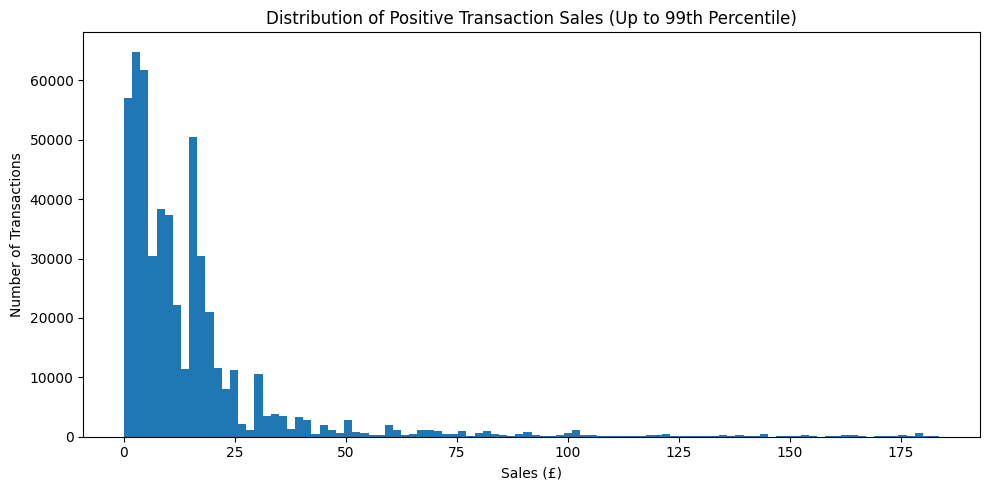

99th percentile: £183.60


In [6]:
# 3.3 Sales Distribution
import matplotlib.pyplot as plt
import seaborn as sns

positive_sales = df.loc[df["Sales"] > 0, "Sales"]

print("\nMinimum Positive Sales :", positive_sales.min())
print("Maximum Positive Sales :", positive_sales.max())

print("\nPositive Sales Quantiles:")
print(
    positive_sales.quantile(
        [0.50, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

sales_upper = positive_sales.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    positive_sales[positive_sales <= sales_upper],
    bins=100
)

plt.title("Distribution of Positive Transaction Sales (Up to 99th Percentile)")
plt.xlabel("Sales (£)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

print(f"99th percentile: £{sales_upper:,.2f}")

,YearMonth,TotalSales
0,2010-12,746723.610
1,2011-01,558448.560
2,2011-02,497026.410
3,2011-03,682013.980
4,2011-04,492367.841
5,2011-05,722094.100
6,2011-06,689977.230
7,2011-07,680156.991
8,2011-08,703510.580
9,2011-09,1017596.682


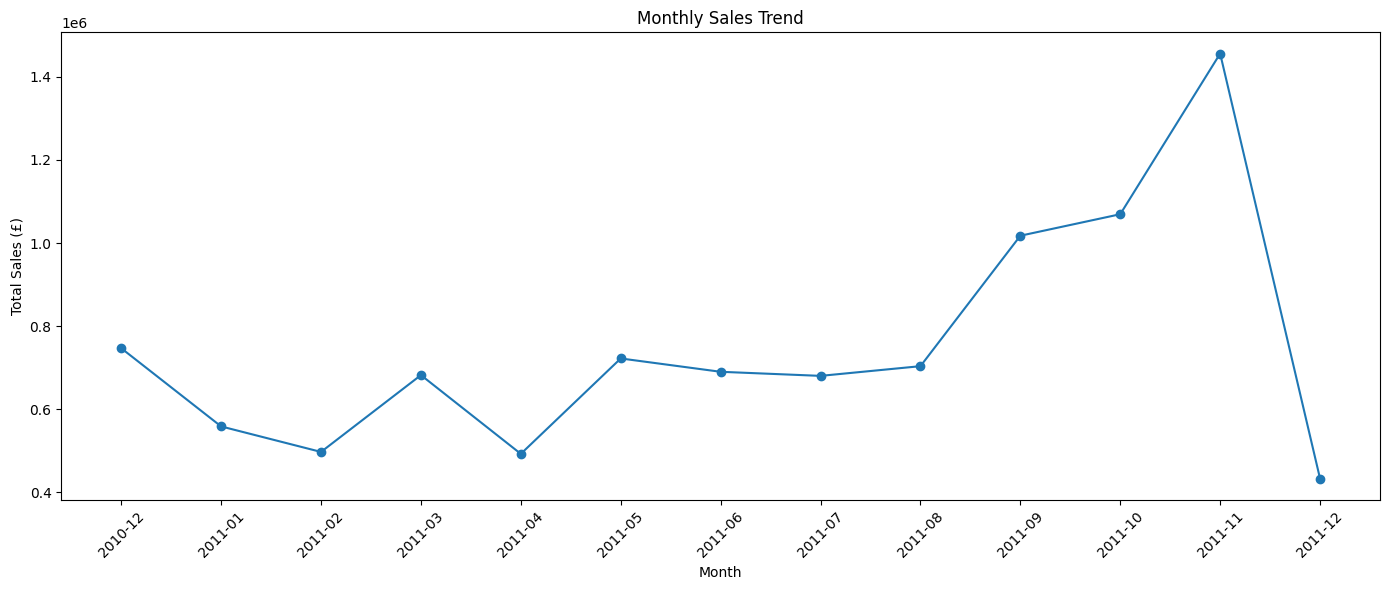

In [7]:
# 3.4 Monthly Sales Trend
sales_summary = (
    df.groupby("YearMonth")
      .agg(
          TotalSales=("Sales", "sum")
      )
      .reset_index()
)
sales_summary["YearMonth"] = sales_summary["YearMonth"].astype(str)

display(sales_summary)

plt.figure(figsize=(14, 6))

plt.plot(
    sales_summary["YearMonth"],
    sales_summary["TotalSales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,YearMonth,TotalQuantity
0,2010-12,358034
1,2011-01,387148
2,2011-02,282950
3,2011-03,376640
4,2011-04,307956
5,2011-05,395085
6,2011-06,388511
7,2011-07,399705
8,2011-08,421836
9,2011-09,569573


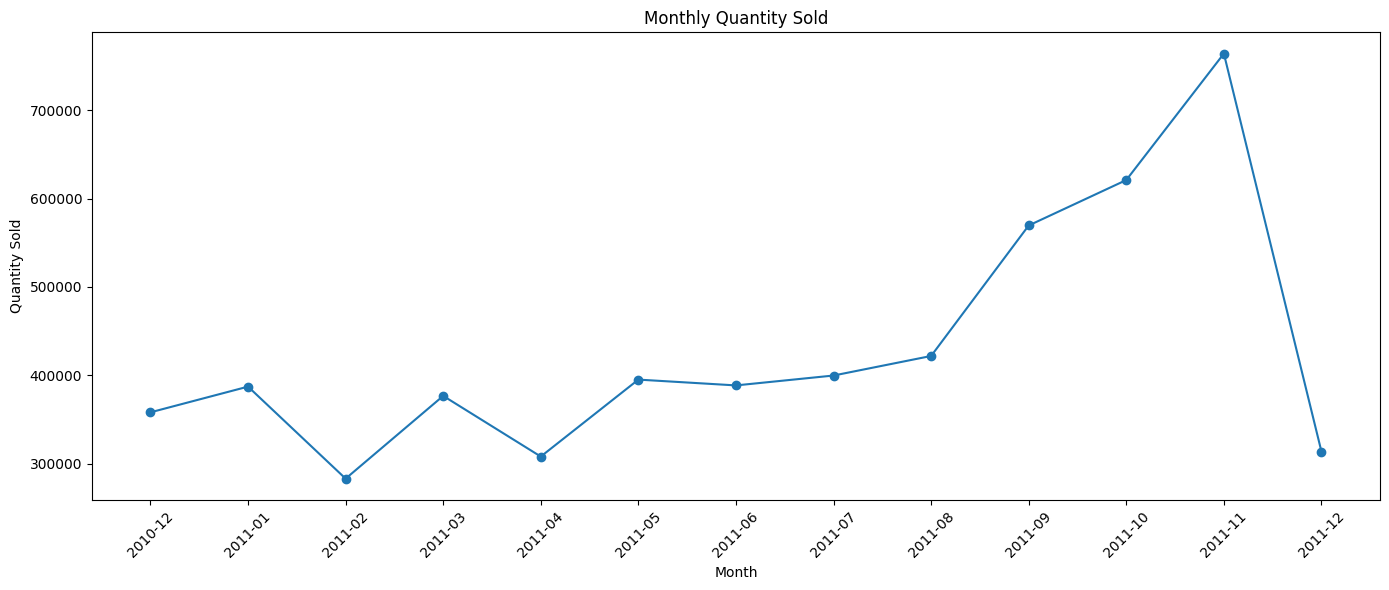

In [8]:
# 3.5 Monthly Quantity Sold
positive_df = df[df["Quantity"] > 0]

quantity_summary = (
    positive_df.groupby("YearMonth")
      .agg(
          TotalQuantity=("Quantity", "sum")
      )
      .reset_index()
)

quantity_summary["YearMonth"] = quantity_summary["YearMonth"].astype(str)

display(quantity_summary)

plt.figure(figsize=(14, 6))

plt.plot(
    quantity_summary["YearMonth"],
    quantity_summary["TotalQuantity"],
    marker="o"
)

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,YearMonth,Transactions
0,2010-12,1885
1,2011-01,1346
2,2011-02,1320
3,2011-03,1772
4,2011-04,1486
5,2011-05,1995
6,2011-06,1862
7,2011-07,1745
8,2011-08,1640
9,2011-09,2170


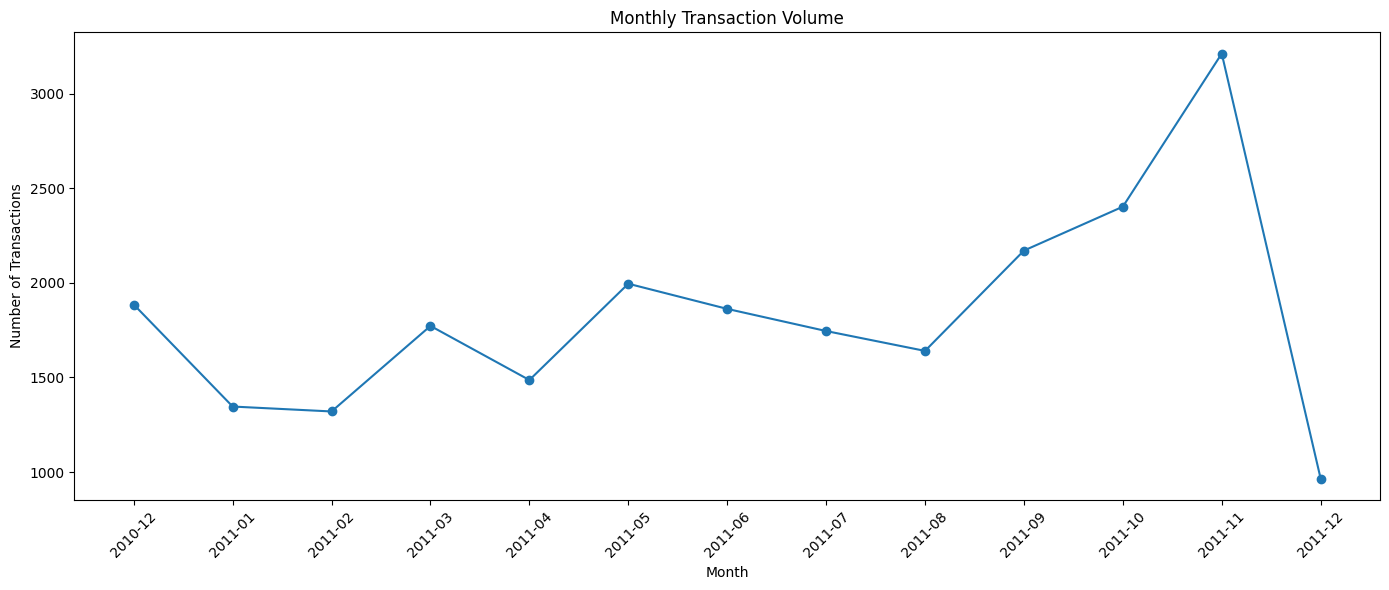

In [9]:
# 3.6 Monthly Transaction Volume
transaction_summary = (
    df.groupby("YearMonth")
      .agg(
          Transactions=("InvoiceNo", "nunique")
      )
      .reset_index()
)

transaction_summary["YearMonth"] = transaction_summary["YearMonth"].astype(str)

display(transaction_summary)

plt.figure(figsize=(14, 6))

plt.plot(
    transaction_summary["YearMonth"],
    transaction_summary["Transactions"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,Country,TotalSales
36,United Kingdom,8189252.304
24,Netherlands,284661.540
10,EIRE,262993.380
14,Germany,221509.470
13,France,197317.110
0,Australia,137009.770
33,Switzerland,56363.050
31,Spain,54756.030
3,Belgium,40910.960
32,Sweden,36585.410


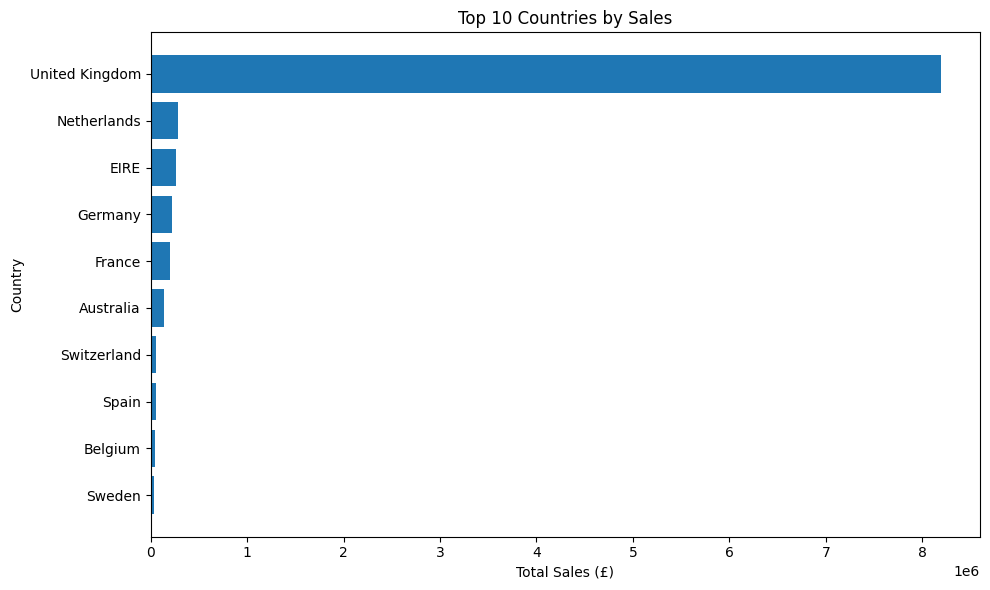

In [10]:
# 3.7. Geographic Sales Distribution
country_sales = (
    df.groupby("Country")
      .agg(
          TotalSales=("Sales", "sum")
      )
      .reset_index()
      .sort_values("TotalSales", ascending=False)
)

display(country_sales.head(15))

top_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"],
    top_countries["TotalSales"]
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

,CustomerID,Transactions
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


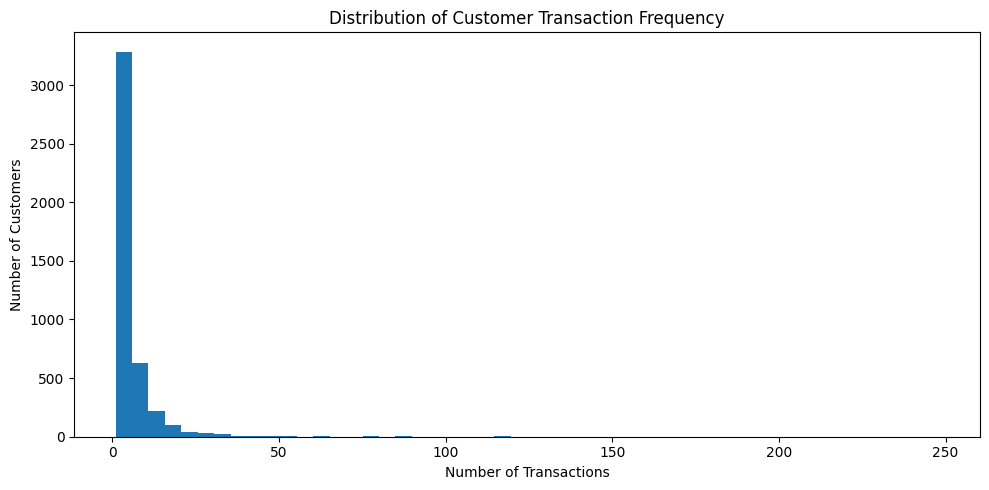

In [11]:
# 3.8 Customer Transaction Activity
customer_activity = (
    df[df["CustomerID"].notna()]
      .groupby("CustomerID")
      .agg(
          Transactions=("InvoiceNo", "nunique")
      )
      .reset_index()
)

display(customer_activity.head())

plt.figure(figsize=(10, 5))

plt.hist(
    customer_activity["Transactions"],
    bins=50
)

plt.title("Distribution of Customer Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 3.9 EDA Summary

The exploratory data analysis revealed several important patterns in the dataset:

- Transaction sales are highly right-skewed, with most transaction lines generating relatively small sales values and a small number of transactions contributing much larger amounts.
- Monthly sales show noticeable fluctuations throughout the observation period, with sales increasing strongly toward the later months of 2011.
- Quantity sold and transaction volume also vary across months, indicating changes in purchasing activity over time.
- Sales are highly concentrated in a small number of countries, while the remaining countries contribute a much smaller share of total sales.
- Customer transaction frequency is highly right-skewed, with most identified customers making relatively few transactions and a small group of customers making purchases much more frequently.

These findings provide a foundation for deeper analysis of sales performance, product performance, and customer behavior in the next stages of the project.

# 4. Sales & Product Analysis

In this step, we analyze sales performance and product-level performance to identify the main revenue drivers and purchasing patterns.

The analysis focuses on total sales, sales by product, quantity sold by product, and the contribution of top-performing products to overall revenue.

,YearMonth,TotalSales
0,2010-12,746723.610
1,2011-01,558448.560
2,2011-02,497026.410
3,2011-03,682013.980
4,2011-04,492367.841
5,2011-05,722094.100
6,2011-06,689977.230
7,2011-07,680156.991
8,2011-08,703510.580
9,2011-09,1017596.682


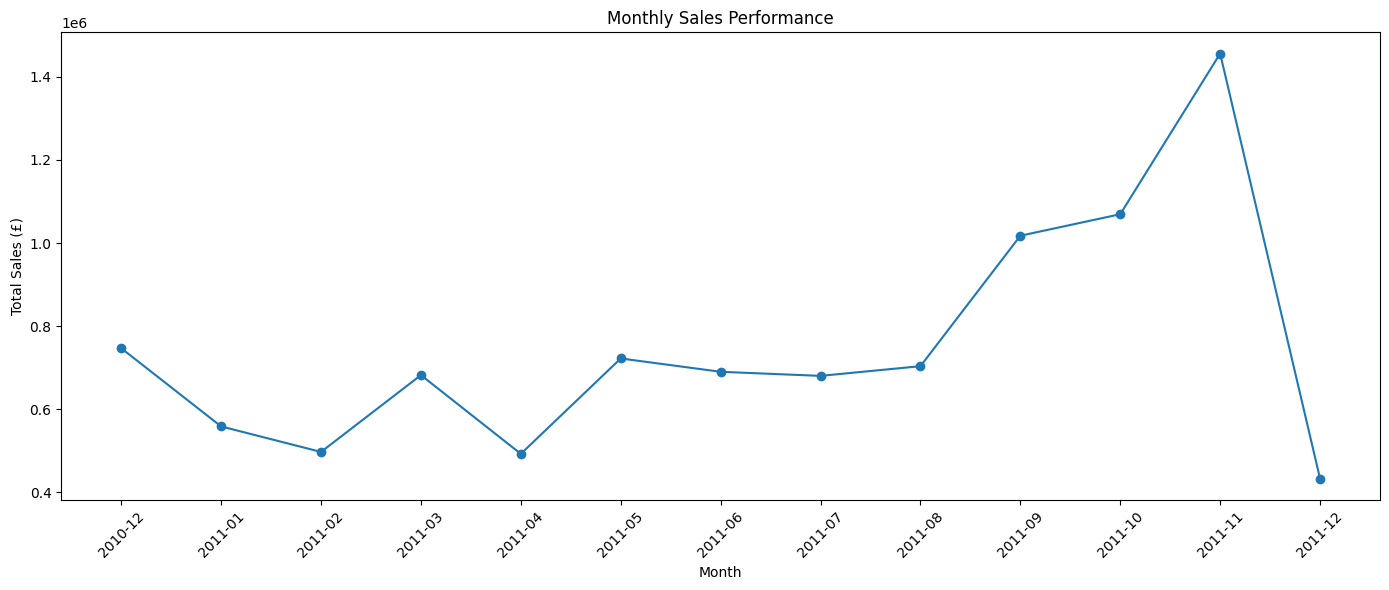

In [12]:
# 4.1 Overall Sales Performance
monthly_sales = (
    df.groupby("YearMonth")
      .agg(
          TotalSales=("Sales", "sum")
      )
      .reset_index()
)

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

display(monthly_sales)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalSales"],
    marker="o"
)

plt.title("Monthly Sales Performance")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Prepare merchandise-level product performance

non_merchandise_codes = ["DOT", "POST", "M", "B", "AMAZONFEE"]

product_performance = (
    df[
        (df["Quantity"] > 0) &
        (~df["StockCode"].isin(non_merchandise_codes))
    ]
    .groupby(["StockCode", "Description"])
    .agg(
        TotalQuantity=("Quantity", "sum"),
        TotalSales=("Sales", "sum")
    )
    .reset_index()
)

product_performance["AverageSellingPrice"] = (
    product_performance["TotalSales"] /
    product_performance["TotalQuantity"]
)

product_performance.head()

,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,0.883593
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,0.393036
2,10120,DOGGY RUBBER,192,40.32,0.210000
3,10125,MINI FUNKY DESIGN TAPES,1295,993.99,0.767560
4,10133,COLOURING PENCILS BROWN TUBE,2856,1539.60,0.539076


,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
1262,22423,REGENCY CAKESTAND 3 TIER,13861,174156.54,12.564500
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2.774993
2669,47566,PARTY BUNTING,18287,99445.23,5.438029
3761,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,1.946617
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.047005
1951,23084,RABBIT NIGHT LIGHT,30739,66870.03,2.175413
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,3.356386
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.620582
2737,79321,CHILLI LIGHTS,10302,54096.36,5.251054


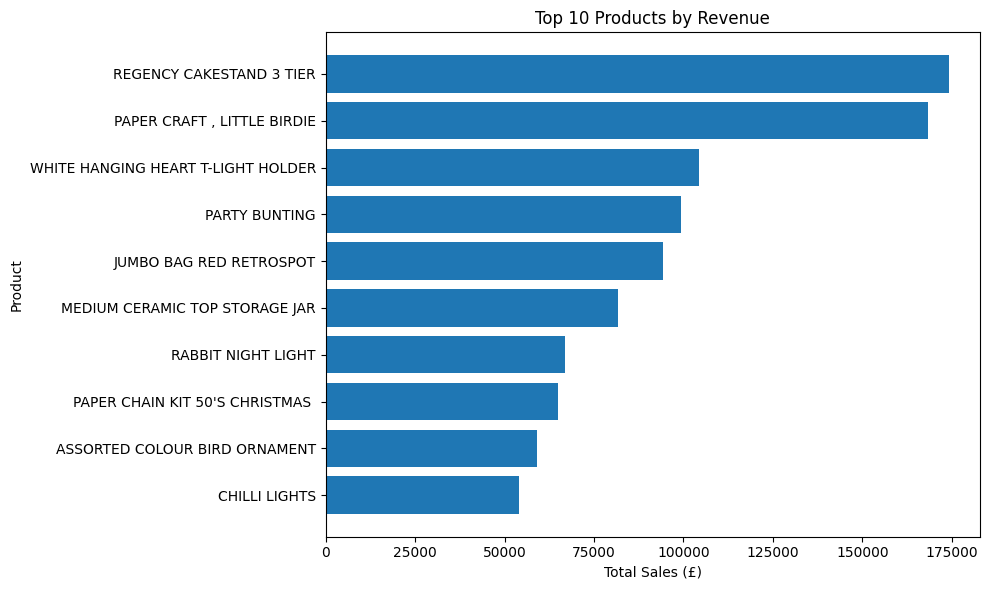

In [14]:
# 4.2 Top Product by Revenue
top_products_revenue = (
    product_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

display(top_products_revenue)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_revenue["Description"],
    top_products_revenue["TotalSales"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Sales (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.047005
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,0.251388
3761,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,1.946617
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2.774993
1051,22197,POPCORN HOLDER,36749,34288.67,0.933050
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,0.583758
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.620582
1951,23084,RABBIT NIGHT LIGHT,30739,66870.03,2.175413
1327,22492,MINI PAINT SET VINTAGE,26633,16937.82,0.635971


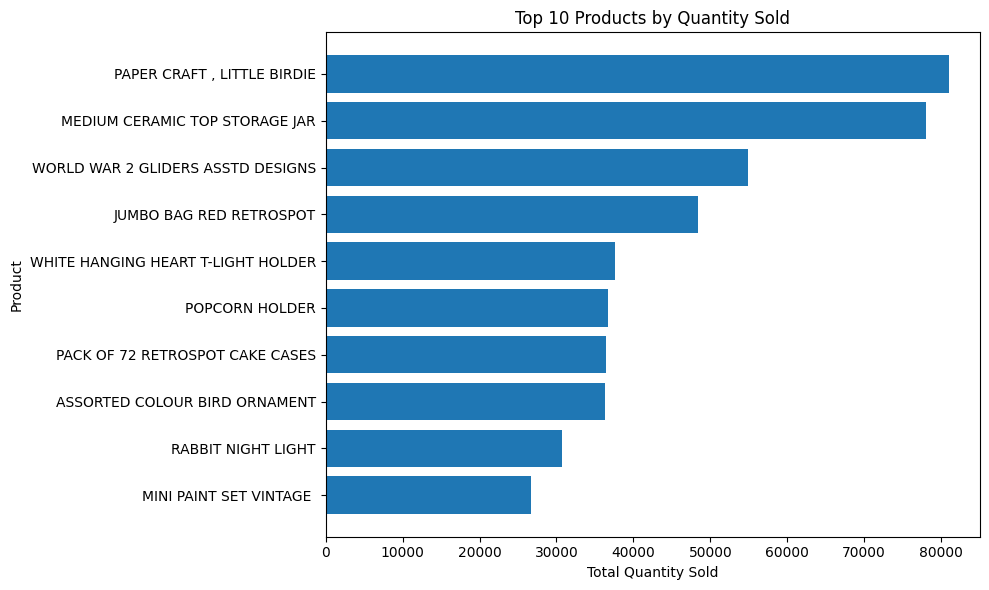

In [15]:
# 4.3 Top Products by Quantity Sold
top_products_quantity = (
    product_performance
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

display(top_products_quantity)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_quantity["Description"],
    top_products_quantity["TotalQuantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,StockCode,Description,TotalSales,RevenueShare
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,1.698229
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.642775
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,1.016893
2669,47566,PARTY BUNTING,99445.23,0.969707
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,0.918168
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,0.796679
1951,23084,RABBIT NIGHT LIGHT,66870.03,0.652061
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,0.632612
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,0.574613
2737,79321,CHILLI LIGHTS,54096.36,0.527502


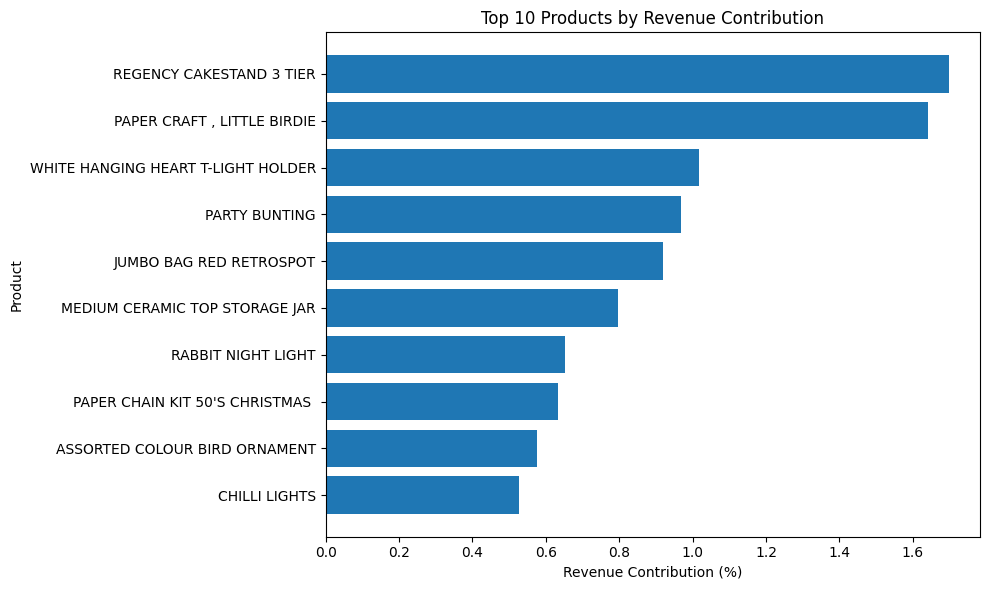

In [16]:
# 4.4 Product Revenue Contribution
total_product_sales = product_performance["TotalSales"].sum()

top_products_revenue = (
    product_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
    .copy()
)

top_products_revenue["RevenueShare"] = (
    top_products_revenue["TotalSales"] / total_product_sales * 100
)

display(
    top_products_revenue[
        ["StockCode", "Description", "TotalSales", "RevenueShare"]
    ]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_revenue["Description"],
    top_products_revenue["RevenueShare"]
)

plt.title("Top 10 Products by Revenue Contribution")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

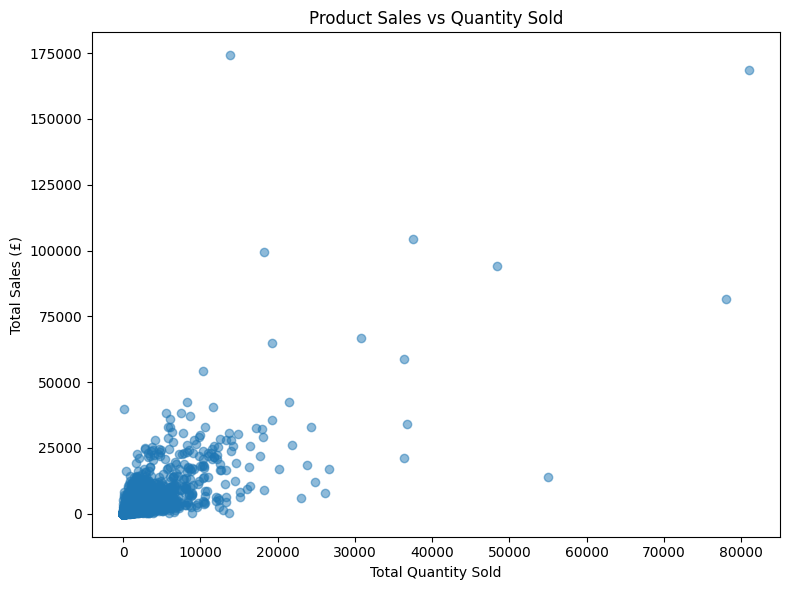

In [17]:
# 4.5 Sales vs Quantity
plt.figure(figsize=(8, 6))

plt.scatter(
    product_performance["TotalQuantity"],
    product_performance["TotalSales"],
    alpha=0.5
)

plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Sales (£)")
plt.title("Product Sales vs Quantity Sold")

plt.tight_layout()
plt.show()

In [18]:
# 4.6 Product Performance Summary
top_quantity = (
    product_performance
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

top_revenue = (
    product_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

top_asp = (
    product_performance
    .sort_values("AverageSellingPrice", ascending=False)
    .head(10)
)

print("Top Products by Quantity")
display(top_quantity)

print("\nTop Products by Revenue")
display(top_revenue)

print("\nTop Products by Average Selling Price")
display(top_asp)

Top Products by Quantity


,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.047005
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,0.251388
3761,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,1.946617
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2.774993
1051,22197,POPCORN HOLDER,36749,34288.67,0.933050
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,0.583758
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.620582
1951,23084,RABBIT NIGHT LIGHT,30739,66870.03,2.175413
1327,22492,MINI PAINT SET VINTAGE,26633,16937.82,0.635971



Top Products by Revenue


,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
1262,22423,REGENCY CAKESTAND 3 TIER,13861,174156.54,12.564500
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2.774993
2669,47566,PARTY BUNTING,18287,99445.23,5.438029
3761,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,1.946617
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.047005
1951,23084,RABBIT NIGHT LIGHT,30739,66870.03,2.175413
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,3.356386
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.620582
2737,79321,CHILLI LIGHTS,10302,54096.36,5.251054



Top Products by Average Selling Price


,StockCode,Description,TotalQuantity,TotalSales,AverageSellingPrice
1337,22502,PICNIC BASKET WICKER 60 PIECES,61,39619.50,649.500000
1663,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,35,5415.00,154.714286
1664,22828,REGENCY MIRROR WITH SHUTTERS,10,1530.00,153.000000
1490,22656,VINTAGE BLUE KITCHEN CABINET,26,3685.00,141.730769
1489,22655,VINTAGE RED KITCHEN CABINET,60,8125.00,135.416667
1659,22823,CHEST NATURAL WOOD 20 DRAWERS,24,2745.00,114.375000
1662,22826,LOVE SEAT ANTIQUE WHITE METAL,58,6210.00,107.068966
883,22016,Dotcomgiftshop Gift Voucher £100.00,1,83.33,83.330000
1766,22929,SCHOOL DESK AND CHAIR,19,1199.75,63.144737
2821,84632,DECORATIVE HANGING SHELVING UNIT,6,359.70,59.950000


### 4.7 Sales & Product Analysis Summary

The sales and product analysis revealed several important patterns:

- Sales performance varies considerably across products, with a relatively small group of products contributing a large share of total sales.
- The products with the highest sales volume are not always the products generating the highest revenue.
- Some products achieve high revenue through relatively high average selling prices, while others generate revenue primarily through high sales volume.
- Several products appear in both the top-quantity and top-revenue rankings, indicating that they are important high-volume revenue drivers.
- Product performance should therefore be evaluated using multiple metrics, including sales revenue, quantity sold, and average selling price, rather than relying on a single metric.
- Products with very high average selling prices but low sales volume should be interpreted carefully, as a high unit price alone does not indicate strong overall product performance.

These findings provide a basis for deeper customer-level analysis in the next stage of the project.

# 5. Customer Analysis

In this step, we analyze customer purchasing behavior using transactions with valid CustomerID values.

The analysis focuses on customer spending, transaction frequency, average order value, and purchasing activity to identify high-value and highly active customers.

,CustomerID,TotalSales,TotalQuantity,Transactions
0,12346.0,0.00,0,2
1,12347.0,4310.00,2458,7
2,12348.0,1797.24,2341,4
3,12349.0,1757.55,631,1
4,12350.0,334.40,197,1
5,12352.0,1545.41,470,11
6,12353.0,89.00,20,1
7,12354.0,1079.40,530,1
8,12355.0,459.40,240,1
9,12356.0,2811.43,1591,3


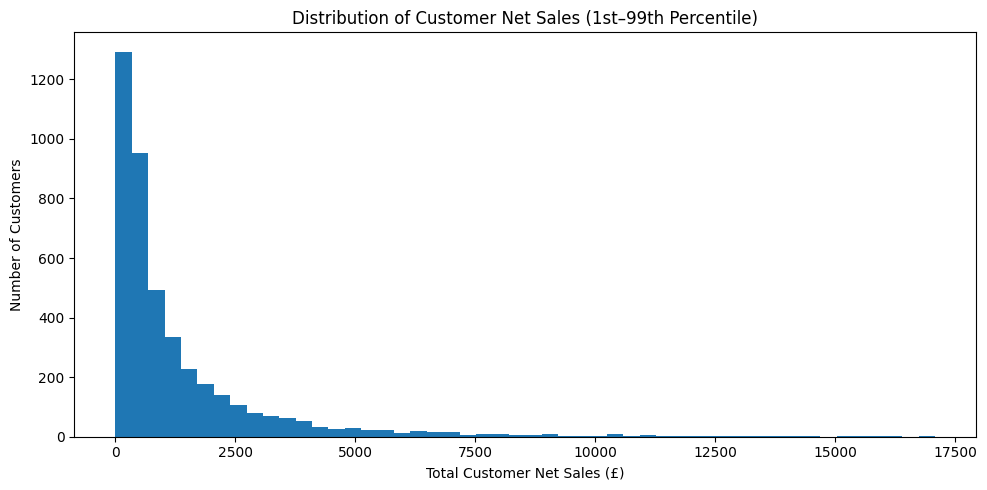

1st percentile : £0.00
99th percentile: £17,226.29


In [19]:
# 5.1 Customer Purchase Summary
customer_summary = (
    df[df["CustomerID"].notna()]
    .groupby("CustomerID")
    .agg(
        TotalSales=("Sales", "sum"),
        TotalQuantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .reset_index()
)

display(customer_summary.head(10))


# Calculate the 1st and 99th percentiles for visualization
sales_lower = customer_summary["TotalSales"].quantile(0.01)
sales_upper = customer_summary["TotalSales"].quantile(0.99)

plot_data = customer_summary[
    (customer_summary["TotalSales"] >= sales_lower) &
    (customer_summary["TotalSales"] <= sales_upper)
]


# Plot customer net sales distribution
plt.figure(figsize=(10, 5))

plt.hist(
    plot_data["TotalSales"],
    bins=50
)

plt.title("Distribution of Customer Net Sales (1st–99th Percentile)")
plt.xlabel("Total Customer Net Sales (£)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print(f"1st percentile : £{sales_lower:,.2f}")
print(f"99th percentile: £{sales_upper:,.2f}")

,TotalSales
0.01,0.0000
0.10,144.9190
0.25,291.7950
0.50,644.0700
0.75,1608.3350
0.90,3496.2010
0.95,5600.2925
0.99,17226.2949


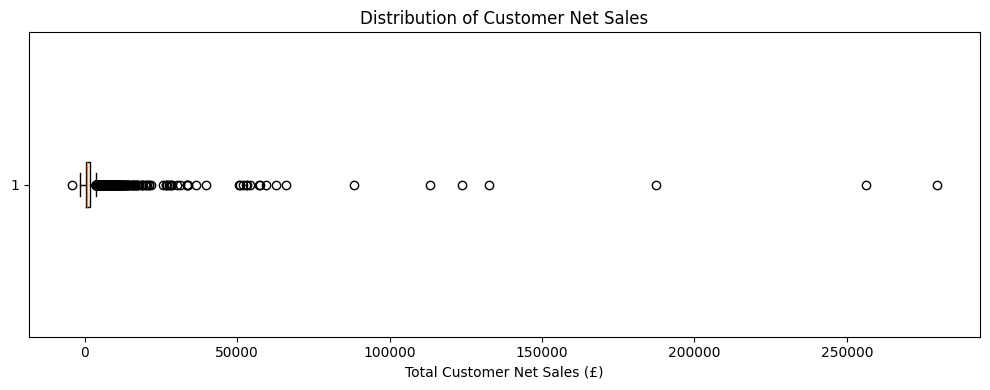

In [20]:
# 5.2 Customer Spending Quantiles
customer_sales_quantiles = customer_summary["TotalSales"].quantile(
    [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(customer_sales_quantiles)

plt.figure(figsize=(10, 4))

plt.boxplot(
    customer_summary["TotalSales"],
    vert=False
)

plt.title("Distribution of Customer Net Sales")
plt.xlabel("Total Customer Net Sales (£)")

plt.tight_layout()
plt.show()


,Transactions
0.25,1.0
0.50,3.0
0.75,5.0
0.90,11.0
0.95,16.0
0.99,36.0


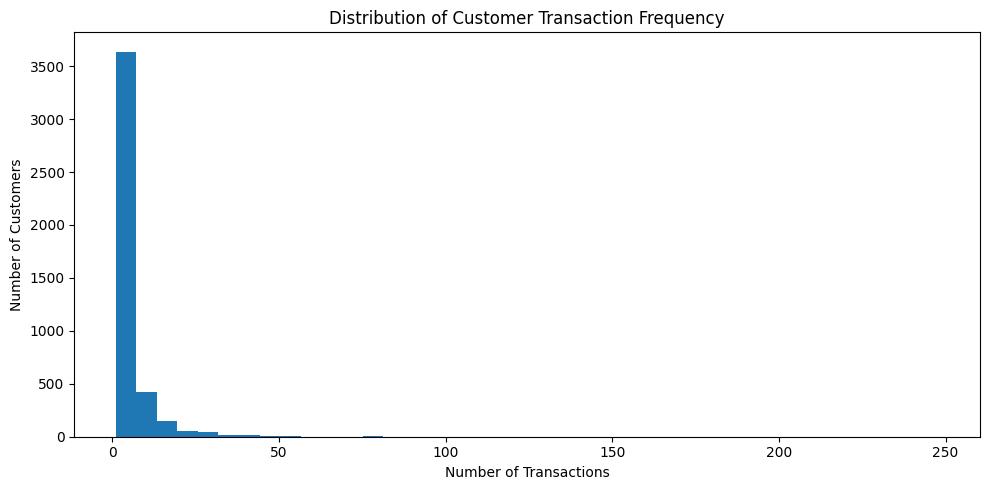

In [21]:
# 5.3 Customer Transaction Frequency
transaction_quantiles = customer_summary["Transactions"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(transaction_quantiles)

plt.figure(figsize=(10, 5))

plt.hist(
    customer_summary["Transactions"],
    bins=40
)

plt.title("Distribution of Customer Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 5.4 Customer Net Average Order Value

Customer Net Average Order Value (Net AOV) is calculated as:

**Net Sales / Number of Unique Invoices**

Because the transaction count may include cancellation invoices, this metric should be interpreted as a net customer-level order value rather than the average value of successful purchases only.

,CustomerID,TotalSales,Transactions,AOV
0,12346.0,0.00,2,0.000000
1,12347.0,4310.00,7,615.714286
2,12348.0,1797.24,4,449.310000
3,12349.0,1757.55,1,1757.550000
4,12350.0,334.40,1,334.400000
5,12352.0,1545.41,11,140.491818
6,12353.0,89.00,1,89.000000
7,12354.0,1079.40,1,1079.400000
8,12355.0,459.40,1,459.400000
9,12356.0,2811.43,3,937.143333


,AOV
0.01,0.000000
0.10,98.868000
0.25,151.430000
0.50,235.154111
0.75,366.518750
0.90,573.436500
0.95,771.514784
0.99,1680.998881


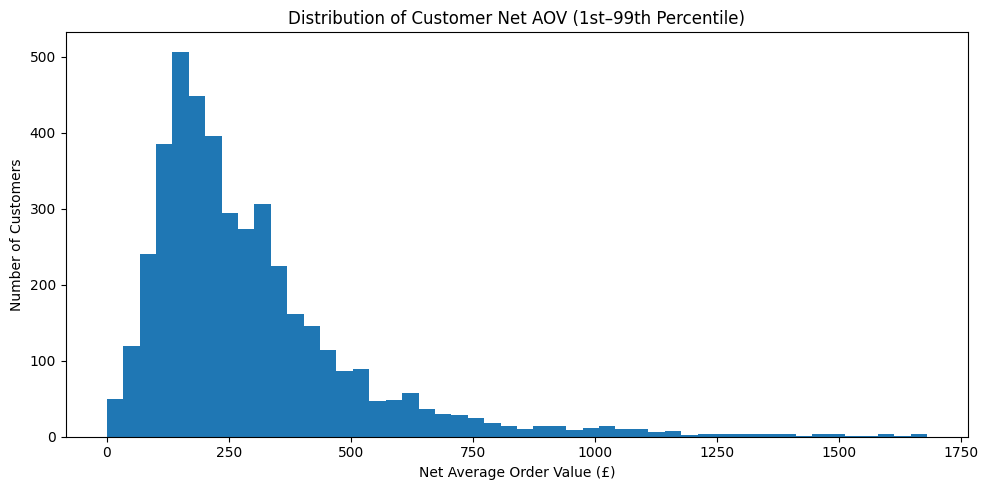

1st percentile : £0.00
99th percentile: £1,681.00


In [22]:
# 5.4 Customer Net Average Order Value (Net AOV)
customer_summary["AOV"] = (
    customer_summary["TotalSales"] /
    customer_summary["Transactions"]
)

display(
    customer_summary[
        ["CustomerID", "TotalSales", "Transactions", "AOV"]
    ].head(10)
)

# Net AOV distribution

aov_quantiles = customer_summary["AOV"].quantile(
    [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(aov_quantiles)

aov_lower = customer_summary["AOV"].quantile(0.01)
aov_upper = customer_summary["AOV"].quantile(0.99)

plot_data = customer_summary[
    (customer_summary["AOV"] >= aov_lower) &
    (customer_summary["AOV"] <= aov_upper)
]

plt.figure(figsize=(10, 5))

plt.hist(
    plot_data["AOV"],
    bins=50
)

plt.title("Distribution of Customer Net AOV (1st–99th Percentile)")
plt.xlabel("Net Average Order Value (£)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print(f"1st percentile : £{aov_lower:,.2f}")
print(f"99th percentile: £{aov_upper:,.2f}")

### 5.5 Customer Analysis Summary

The customer analysis revealed several important patterns in customer purchasing behavior:

- Customer spending is highly right-skewed, with most customers generating relatively low net sales and a small group contributing substantially higher sales values.
- Customer transaction frequency is also highly right-skewed. Most customers make relatively few transactions, while a small group purchases much more frequently.
- Average Order Value (AOV) varies considerably across customers and shows a right-skewed distribution, indicating that some customers place orders with substantially higher average values.
- Transaction frequency and AOV capture different aspects of customer behavior. A customer may purchase frequently without having a high AOV, while another customer may purchase less frequently but generate higher-value orders.
- A small group of customers shows exceptionally high spending, transaction frequency, or AOV. This may indicate wholesale, business, or high-value purchasing behavior, although the dataset does not provide sufficient information to determine the exact customer type.
- These differences suggest that customer value should be evaluated using multiple dimensions rather than a single metric.

These findings provide the foundation for **RFM Customer Segmentation**, which combines Recency, Frequency, and Monetary value to identify groups of customers with different purchasing behaviors.

# 6. RFM Customer Segmentation

In this step, we apply **RFM (Recency, Frequency, Monetary) analysis** to evaluate customer purchasing behavior and segment customers based on their level of engagement and value.

RFM consists of three dimensions:

* **Recency (R):** How recently a customer made a purchase.
* **Frequency (F):** How often a customer made purchases.
* **Monetary (M):** How much revenue a customer generated from purchases.

For this analysis, RFM metrics are calculated using transactions with valid `CustomerID` values and successful purchase activity.

Because the dataset contains cancellation transactions, cancellations are excluded from the core RFM calculation so that they do not artificially affect purchase recency or frequency. Monetary value therefore represents revenue generated from successful purchases rather than customer net sales after cancellations.

The Recency reference date is based on the end of the dataset observation period rather than the current date.

The objective of this analysis is to identify differences in customer purchasing behavior and group customers into meaningful segments that can support customer retention, targeting, and relationship management decisions.


In [23]:
#6.1 RFM Data Preparation
rfm_base = df[
    (df["CustomerID"].notna()) &
    (df["Quantity"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

rfm_base.shape

print("Missing CustomerID:", rfm_base["CustomerID"].isna().sum())
print("Quantity <= 0:", (rfm_base["Quantity"] <= 0).sum())
print(
    "Cancellation invoices:",
    rfm_base["InvoiceNo"].astype(str).str.startswith("C").sum()
)

print("First purchase date:", rfm_base["InvoiceDate"].min())
print("Last purchase date:", rfm_base["InvoiceDate"].max())

reference_date = rfm_base["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Missing CustomerID: 0
Quantity <= 0: 0
Cancellation invoices: 0
First purchase date: 2010-12-01 08:26:00
Last purchase date: 2011-12-09 12:50:00


Timestamp('2011-12-10 12:50:00')

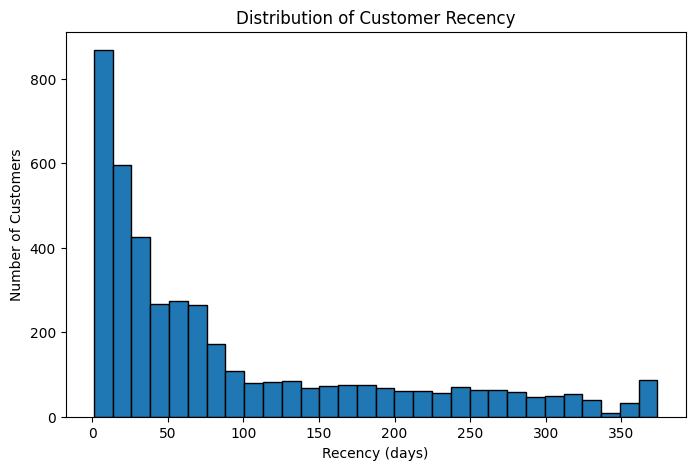

In [24]:
# 6.2 Recency
recency = (
    rfm_base.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

recency["Recency"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

recency["Recency"].describe()

plt.figure(figsize=(8, 5))

plt.hist(recency["Recency"], bins=30, edgecolor="black")

plt.xlabel("Recency (days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")

plt.show()

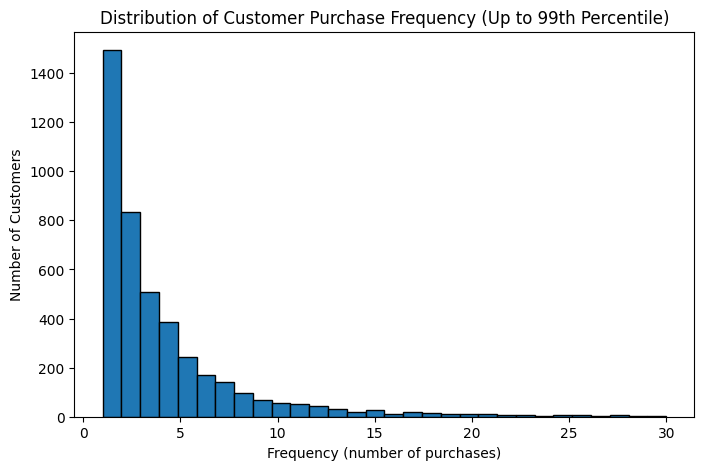

In [25]:
# 6.3 Frequency
frequency = (
    rfm_base.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index(name="Frequency")
)

frequency["Frequency"].describe()

frequency["Frequency"].quantile([0.90, 0.95, 0.99])

freq_99 = frequency["Frequency"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    frequency.loc[frequency["Frequency"] <= freq_99, "Frequency"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Frequency (number of purchases)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Purchase Frequency (Up to 99th Percentile)")

plt.show()

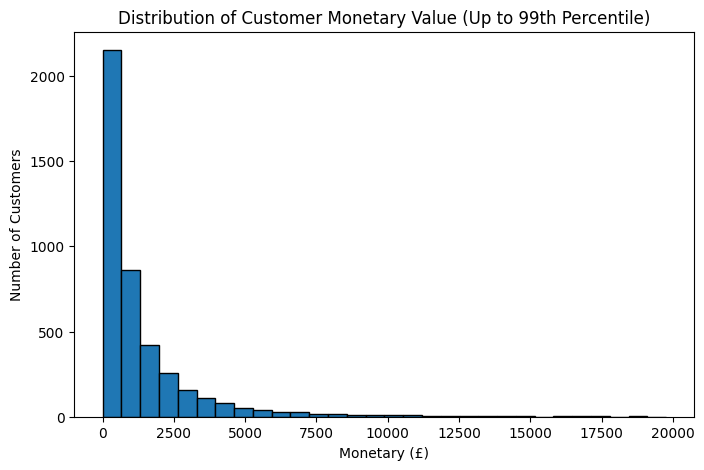

In [26]:
# 6.4 Monetary
monetary = (
    rfm_base.groupby("CustomerID")["Sales"]
    .sum()
    .reset_index(name="Monetary")
)

monetary["Monetary"].describe()

monetary["Monetary"].quantile([0.90, 0.95, 0.99])

monetary_99 = monetary["Monetary"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    monetary.loc[monetary["Monetary"] <= monetary_99, "Monetary"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Monetary (£)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Monetary Value (Up to 99th Percentile)")

plt.show()

In [27]:
# 6.5 RFM Score
rfm = (
    recency[["CustomerID", "Recency"]]
    .merge(frequency, on="CustomerID")
    .merge(monetary, on="CustomerID")
)

print("RFM shape:", rfm.shape)
print("Missing values:", rfm.isna().sum().sum())

r_q = rfm["Recency"].quantile([0.25, 0.50, 0.75])
f_q = rfm["Frequency"].quantile([0.25, 0.50, 0.75])
m_q = rfm["Monetary"].quantile([0.25, 0.50, 0.75])

rfm["R_Score"] = pd.cut(
    rfm["Recency"],
    bins=[-np.inf, r_q[0.25], r_q[0.50], r_q[0.75], np.inf],
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.cut(
    rfm["Frequency"],
    bins=[-np.inf, f_q[0.25], f_q[0.50], f_q[0.75], np.inf],
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.cut(
    rfm["Monetary"],
    bins=[-np.inf, m_q[0.25], m_q[0.50], m_q[0.75], np.inf],
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head()

RFM shape: (4339, 4)
Missing values: 0


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,326,1,77183.60,1,1,4,114,6
1,12347.0,2,7,4310.00,4,4,4,444,12
2,12348.0,75,4,1797.24,2,3,4,234,9
3,12349.0,19,1,1757.55,3,1,4,314,8
4,12350.0,310,1,334.40,1,1,2,112,4


In [28]:
# 6.6 Customer Segments
conditions = [
    (rfm["R_Score"] == 4) & (rfm["F_Score"] == 4),

    (rfm["R_Score"].isin([3, 4])) &
    (rfm["F_Score"].isin([3, 4])),

    (rfm["R_Score"] == 4) &
    (rfm["F_Score"].isin([1, 2])),

    (rfm["R_Score"] == 3) &
    (rfm["F_Score"].isin([1, 2])),

    (rfm["R_Score"].isin([1, 2])) &
    (rfm["F_Score"].isin([3, 4])),

    (rfm["R_Score"] == 2) &
    (rfm["F_Score"].isin([1, 2])),

    (rfm["R_Score"] == 1) &
    (rfm["F_Score"].isin([1, 2]))
]

segments = [
    "Champions",
    "Loyal Customers",
    "Recent Customers",
    "Promising",
    "At Risk",
    "Need Attention",
    "Hibernating"
]

rfm["Segment"] = np.select(
    conditions,
    segments,
    default="Other"
)

rfm["Segment"].value_counts()


,count
Segment,
Hibernating,946
Loyal Customers,920
Need Attention,643
At Risk,561
Champions,529
Promising,471
Recent Customers,269


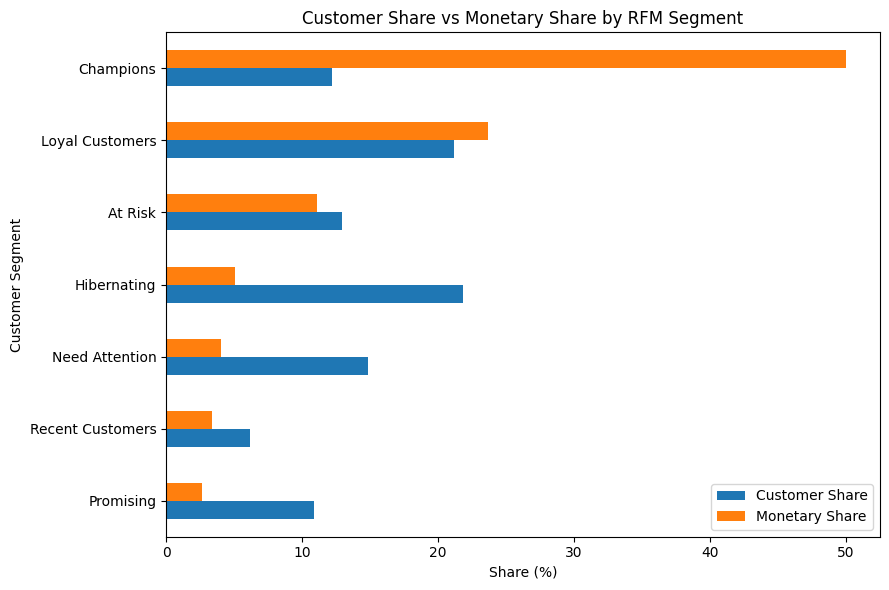

In [29]:
# 6.7 Segment Analysis
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
    .sort_values("Customers", ascending=False)
)

segment_summary

segment_summary["CustomerShare"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
)

segment_summary["MonetaryShare"] = (
    segment_summary["TotalMonetary"]
    / segment_summary["TotalMonetary"].sum()
    * 100
)

segment_summary[
    ["Customers", "CustomerShare", "TotalMonetary", "MonetaryShare"]
].round(2)

share_plot = (
    segment_summary[
        ["CustomerShare", "MonetaryShare"]
    ]
    .sort_values("MonetaryShare", ascending=True)
)

share_plot.plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Share (%)")
plt.ylabel("Customer Segment")
plt.title("Customer Share vs Monetary Share by RFM Segment")
plt.legend(["Customer Share", "Monetary Share"])
plt.tight_layout()

plt.show()

## Step 6 Summary — RFM Customer Segmentation

RFM analysis was conducted on **4,339 customers** using successful purchase transactions with valid `CustomerID` values.

The analysis evaluated customers based on three dimensions:

- **Recency:** how recently a customer made a successful purchase
- **Frequency:** how often a customer made successful purchases
- **Monetary:** how much revenue the customer generated from successful purchases

The distributions of all three RFM metrics were right-skewed, indicating that customer activity and value are concentrated among a relatively small group.

Customers were segmented into seven behavioral groups based primarily on Recency and Frequency scores:

- Champions
- Loyal Customers
- Recent Customers
- Promising
- At Risk
- Need Attention
- Hibernating

The **Champions** segment represents **12.19% of customers** but contributes approximately **49.99% of total Monetary value**, showing a strong concentration of purchase value among highly recent and frequent customers.

**Loyal Customers** account for **21.20% of customers** and contribute approximately **23.67% of Monetary value**.

In contrast, **Hibernating customers** form the largest segment at **21.80% of customers**, but contribute only **5.11% of Monetary value**.

The **At Risk** segment accounts for **12.93% of customers** and contributes **11.14% of Monetary value**, making it an important group for potential retention or reactivation efforts.

Overall, the RFM analysis highlights substantial differences in customer engagement and value, providing a practical basis for customer targeting, retention, and relationship management strategies.

> Note: Monetary value in this RFM analysis represents revenue from successful purchase transactions and does not include cancellation adjustments.

# 7. Cohort & Retention Analysis

In this step, we analyze customer retention over time using **cohort analysis**.

Customers are grouped into cohorts based on the month of their **first successful purchase**. We then track how many customers from each cohort return and make additional purchases in subsequent months.

The analysis focuses on:

- Identifying the first purchase month for each customer
- Assigning customers to acquisition cohorts
- Measuring monthly customer retention
- Comparing retention patterns across cohorts
- Identifying changes in repeat purchasing behavior over time

For consistency with the RFM analysis, cohort analysis is based on successful purchase transactions with valid `CustomerID` values. Cancellation transactions are excluded because they do not represent successful purchasing activity.

The objective is to understand how effectively customers are retained after their initial purchase and whether certain acquisition cohorts demonstrate stronger repeat purchasing behavior than others.

In [30]:
# 7.1 Cohort data preparation
# Use complete months only for cohort retention analysis

cohort_base = rfm_base[
    rfm_base["InvoiceDate"] < "2011-12-01"
].copy()

cohort_base["InvoiceMonth"] = (
    cohort_base["InvoiceDate"].dt.to_period("M")
)

cohort_base["CohortMonth"] = (
    cohort_base.groupby("CustomerID")["InvoiceMonth"]
    .transform("min")
)

cohort_base.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Date,Year,Month,YearMonth,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010,12,2010-12,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010,12,2010-12,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010,12,2010-12,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010,12,2010-12,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010,12,2010-12,2010-12,2010-12


In [31]:
# 7.2 Create CohortIndex
cohort_base["CohortIndex"] = (
    (cohort_base["InvoiceMonth"].dt.year - cohort_base["CohortMonth"].dt.year) * 12
    + (cohort_base["InvoiceMonth"].dt.month - cohort_base["CohortMonth"].dt.month)
    + 1
)

cohort_base[
    ["CustomerID", "InvoiceMonth", "CohortMonth", "CohortIndex"]
].head()

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,1
1,17850.0,2010-12,2010-12,1
2,17850.0,2010-12,2010-12,1
3,17850.0,2010-12,2010-12,1
4,17850.0,2010-12,2010-12,1


In [32]:
# 7.3 Caculate retention
cohort_counts = (
    cohort_base.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .unstack()
)

cohort_size = cohort_counts[1]

retention = cohort_counts.divide(cohort_size, axis=0)

retention.round(3)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


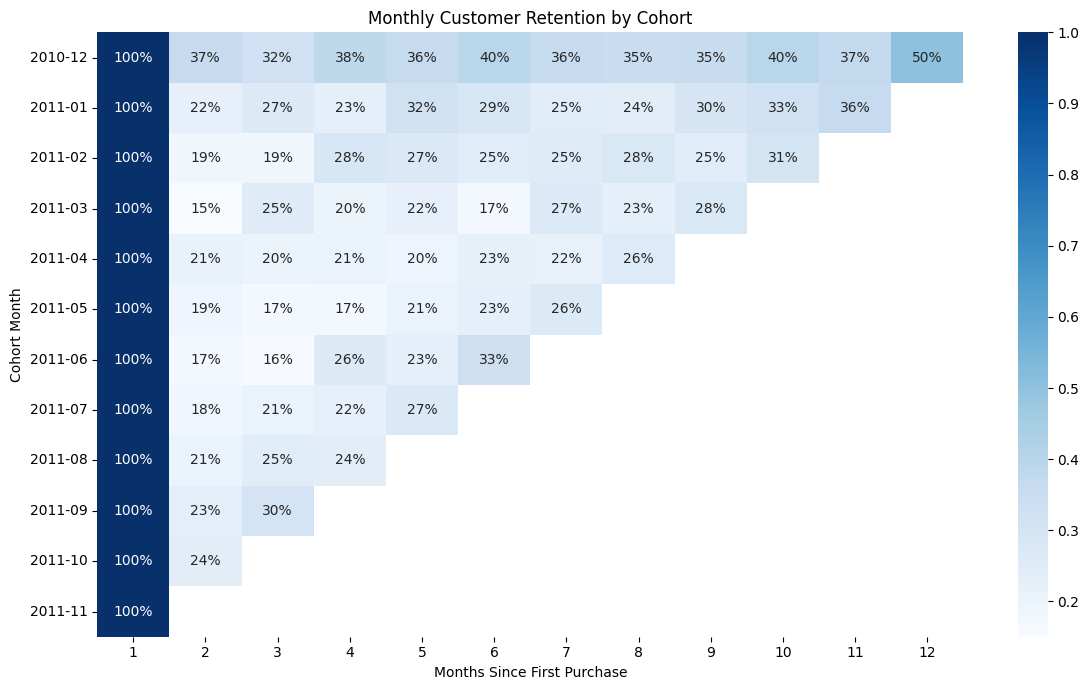

In [33]:
# 7.4 Heatmap
plt.figure(figsize=(12, 7))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Monthly Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

## Step 7 Summary — Cohort & Retention Analysis

Cohort analysis was used to evaluate customer retention by grouping customers according to the month of their first observed successful purchase.

To avoid bias from incomplete data, **December 2011 was excluded from the retention analysis** because the dataset only contains transactions through December 9, 2011.

Retention generally decreases after the initial purchase month, showing that only a portion of customers return to make purchases in subsequent months.

The **December 2010 cohort** shows the strongest long-term retention, with retention generally remaining around the 30%–40% range across many observed months and reaching approximately **50% in Month 12**.

For most 2011 cohorts, second-month retention is generally lower, often around **15%–24%**, although retention varies across cohorts and may increase in later months.

Overall, the analysis suggests that repeat purchasing after the first observed transaction is relatively limited for many customer cohorts, while a smaller proportion of customers continues purchasing over longer periods.

A key limitation is that customers in the earliest cohort may have purchased before the dataset observation period. Therefore, `CohortMonth` represents the customer's **first observed purchase month**, not necessarily their true first-ever purchase month.

# 8. Business Insights & Recommendations

This section summarizes the key findings from the sales, product, customer, RFM, and cohort analyses and translates them into practical business recommendations.

The objective is not only to describe what happened in the dataset, but also to identify important customer and revenue patterns that may support decisions related to customer retention, product strategy, and customer relationship management.

Recommendations are based only on patterns observed in the available data. Where the dataset does not provide sufficient evidence to determine the underlying cause, conclusions are presented as potential business actions rather than definitive explanations.

## 8.1 Key Business Insights

### 1. Revenue is concentrated among a relatively small group of customers

Customer value is highly uneven across the dataset. RFM analysis shows that the **Champions** segment represents only **12.19% of customers** but contributes approximately **49.99% of total Monetary value**.

Together, **Champions** and **Loyal Customers** account for a large share of customer purchase value, indicating that a relatively small group of highly active customers plays an important role in overall revenue generation.

### 2. A large proportion of customers show low or declining engagement

The **Hibernating** segment is the largest customer group, representing **21.80% of customers**, but contributes only **5.11% of Monetary value**.

In addition, the **At Risk** segment represents **12.93% of customers** and contributes approximately **11.14% of Monetary value**. These customers previously showed stronger purchasing activity but have not purchased as recently as higher-engagement segments.

### 3. Customer purchasing behavior is highly right-skewed

Customer spending, purchase frequency, and net average order value are all strongly right-skewed.

Most customers make relatively few purchases and generate moderate revenue, while a small number of customers show substantially higher purchase frequency and monetary value.

This indicates that customer performance should not be evaluated using averages alone, as a relatively small group of high-value customers can significantly influence overall metrics.

### 4. High sales volume does not always translate into the highest product revenue

Product analysis showed that products with the highest sales quantities are not necessarily the products generating the most revenue.

For example, `23843 - PAPER CRAFT, LITTLE BIRDIE` sold **80,995 units** and generated approximately **£168,469.60**, while `22423 - REGENCY CAKESTAND 3 TIER` sold only **13,861 units** but generated a higher revenue of approximately **£174,156.54**.

This demonstrates that product performance should be assessed using multiple metrics such as sales quantity, revenue, and average selling price rather than sales volume alone.

### 5. Customer retention drops substantially after the first observed purchase

Cohort analysis shows that customer retention generally decreases after the initial purchase month.

For many 2011 cohorts, second-month retention is approximately in the **15%–24% range**, indicating that only a portion of newly acquired customers return to purchase again in the following month.

The December 2010 cohort shows stronger retention across several observed periods, although this cohort should be interpreted carefully because the dataset begins in December 2010 and may not capture the customers' true first-ever purchases.

### 6. Customer activity and revenue are concentrated rather than evenly distributed

Across the sales, customer, and RFM analyses, a consistent pattern emerges: business performance is driven disproportionately by a relatively small number of products and customers.

This concentration creates both an opportunity and a risk. High-value customers and products can contribute strongly to business performance, but excessive dependence on a small group may also increase vulnerability if their purchasing behavior changes.

## 8.2 Business Recommendations

### 1. Prioritize retention of Champions and Loyal Customers

Because **Champions** and **Loyal Customers** contribute a disproportionately large share of Monetary value, the business should prioritize maintaining engagement with these customers.

Potential actions include:

- Personalized offers or loyalty benefits
- Early access to new or high-demand products
- Targeted communication based on previous purchasing behavior
- Relationship-building initiatives designed to encourage repeat purchases

The objective should be to protect the value generated by these high-performing customer groups rather than focusing only on acquiring new customers.

### 2. Develop reactivation strategies for At Risk customers

The **At Risk** segment still shows meaningful historical purchasing activity and Monetary value but has not purchased as recently as stronger segments.

Potential actions include:

- Win-back campaigns
- Personalized reminders based on previous purchases
- Limited-time incentives
- Product recommendations related to past buying behavior

This segment may provide a useful reactivation opportunity because these customers have already demonstrated prior engagement.

### 3. Use lighter-cost strategies for Hibernating customers

The **Hibernating** segment represents a large share of customers but contributes a relatively small share of Monetary value.

Instead of investing heavily in individualized campaigns, the business could use lower-cost re-engagement approaches such as:

- Automated email campaigns
- Broad promotional offers
- Seasonal reminders
- Product discovery campaigns

Customers who respond positively can then be moved into more targeted retention programs.

### 4. Focus on improving repeat purchases after the first observed purchase

Cohort analysis shows that retention generally falls substantially after the first observed purchase.

The business should therefore focus on increasing the probability of a second purchase, especially during the first few months after acquisition.

Potential strategies include:

- Post-purchase follow-up communication
- Second-purchase incentives
- Personalized product recommendations
- Cross-selling and complementary product suggestions

Improving early repeat-purchase behavior may help strengthen longer-term customer retention.

### 5. Evaluate product performance using multiple metrics

Product decisions should not rely on sales volume alone.

The analysis shows that high-volume products do not always generate the highest revenue. Product performance should therefore be evaluated using a combination of:

- Quantity sold
- Revenue generated
- Average selling price
- Customer demand patterns

This approach can help distinguish high-volume products from high-value products and support more balanced merchandising decisions.

### 6. Reduce dependency on a small number of high-value customers

Because a relatively small customer group contributes a large share of Monetary value, the business may be exposed to customer concentration risk.

Potential actions include:

- Retaining existing high-value customers
- Encouraging Promising and Recent Customers to increase purchase frequency
- Developing customers in mid-value segments
- Monitoring whether revenue concentration becomes more extreme over time

The goal is not to reduce the importance of high-value customers, but to gradually broaden the customer base contributing meaningful revenue.

### 7. Monitor customer segments over time

RFM segments represent customer behavior at a specific point within the observation period. Customers may move between segments as their purchasing behavior changes.

The business should periodically recalculate RFM metrics to identify:

- Customers moving into higher-value segments
- Loyal customers beginning to become inactive
- Recent customers developing repeat-purchase behavior
- At Risk customers who successfully reactivate

Tracking segment movement over time can make customer targeting more dynamic and actionable.

## 8.3 Analysis Limitations

Although the analysis provides useful insights into sales and customer behavior, several limitations should be considered when interpreting the results.

### 1. Limited observation period

The dataset covers transactions from **December 1, 2010 to December 9, 2011**.

Because the observation period is approximately one year, the analysis may not capture longer-term purchasing patterns or seasonality across multiple years.

In addition, December 2011 contains only partial-month data. Therefore, it was excluded from the cohort retention analysis to ensure that retention rates are based only on complete months.

### 2. Incomplete customer identification

Some transactions do not contain a valid `CustomerID`.

These transactions were retained for transaction-level, product, and geographic analyses, but excluded from customer-level analyses such as Customer Analysis, RFM, and Cohort Analysis.

As a result, customer-level findings represent only transactions where customer identity is available.

### 3. Cohort analysis reflects first observed purchase

Customers are assigned to cohorts based on their first successful purchase observed within the dataset.

For customers appearing at the beginning of the observation period, especially the **December 2010 cohort**, this may not represent their true first-ever purchase.

Therefore, cohort results should be interpreted as retention since the **first observed purchase**, rather than confirmed customer acquisition.

### 4. RFM segmentation is rule-based

RFM scores were created using quartile-based thresholds and customers were assigned to behavioral segments primarily using Recency and Frequency scores.

These segment definitions provide a practical framework for customer analysis, but they are analytical rules rather than verified customer categories.

Frequency scores are also not evenly distributed because many customers have identical purchase frequencies.

### 5. Monetary value differs from net sales

The Monetary metric used in RFM represents revenue from **successful purchase transactions**.

Cancellation transactions are excluded from RFM so that they do not distort purchasing Recency and Frequency. Therefore, RFM Monetary should not be interpreted as customer net sales after cancellations.

### 6. Limited customer and business context

The dataset does not provide detailed information about customer demographics, acquisition channels, marketing campaigns, customer type, product costs, or profit margins.

As a result, the analysis can identify behavioral patterns but cannot definitively explain why those patterns occurred.

For example, customers with unusually high purchase values may represent wholesale, business, or other high-volume purchasing behavior, but the available data is not sufficient to confirm the exact customer type.

### 7. Recommendations should be treated as potential actions

The business recommendations in this project are derived from observed transaction patterns rather than controlled experiments.

Strategies such as retention campaigns, personalized offers, or reactivation incentives should therefore be tested and evaluated using additional business data before being implemented at scale.